In [1]:
#Librerias a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


 # 0.1 Cargar solo columnas necesarias

In [2]:
# Viviendas
cols_vivienda = [
    "id_vivienda",
    "region",
    "comuna",            # en el diccionario aparece como "comuna"
    "p4a_mat_paredes",   # materialidad paredes
    "p4b_mat_techo",     # materialidad techo
    "p4c_mat_piso",       # materialidad piso
    "indice_hacinamiento"   # índice de hacinamiento, en la tarea aparece en hogar, pero en el diccionario aparece en vivienda
]

vivienda = pd.read_parquet(
    "viviendas_censo2024.parquet",
    columns=cols_vivienda
)

# Hogares
cols_hogar = [
    "id_vivienda",
    "id_hogar",
    "p12_tenencia_viv"      # tenencia
]

hogar = pd.read_parquet(
    "hogares_censo2024.parquet",
    columns=cols_hogar
)

# Personas
cols_persona = [
    "id_vivienda",
    "id_hogar",
    "id_persona",
    "sexo",
    "edad",
    "p27_nacionalidad_esp",
    "p25_lug_nacimiento_rec",
    "p24_lug_resid5",
    "p25_lug_nacimiento",
    "p26_llegada_periodo",
    "escolaridad",
    "cine11",
    "sit_fuerza_trabajo",
    "cod_ciuo",
    "cod_caenes",
    "p45_medio_transporte"
]

persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=cols_persona
)


# 0.2 Filtar las comunas

In [3]:
# Primero: persona + hogar
persona_hogar = persona.merge(
    hogar,
    on=["id_vivienda", "id_hogar"],
    how="left"
)
# Luego: + vivienda
censo = persona_hogar.merge(
    vivienda,
    on="id_vivienda",
    how="left"
)

# ----------------------------
# Revisar resultado
# ----------------------------
print("Vivienda:", vivienda.shape)
print("Hogar:", hogar.shape)
print("Persona:", persona.shape)
print("Base final:", censo.shape)

#Vemos como quedó la base final luego de los joins
censo.head()

Vivienda: (7664466, 7)
Hogar: (6622597, 3)
Persona: (18480432, 16)
Base final: (18480432, 23)


,id_vivienda,id_hogar,id_persona,sexo,edad,p27_nacionalidad_esp,p25_lug_nacimiento_rec,p24_lug_resid5,p25_lug_nacimiento,p26_llegada_periodo,...,cod_ciuo,cod_caenes,p45_medio_transporte,p12_tenencia_viv,region,comuna,p4a_mat_paredes,p4b_mat_techo,p4c_mat_piso,indice_hacinamiento
0,1,1,1,2,80,152,1,3,2,NaN,...,NaN,NaN,NaN,4.0,5,5802,5.0,1.0,2.0,1.0
1,1,1,2,1,52,152,1,2,2,NaN,...,7.0,F,2.0,4.0,5,5802,5.0,1.0,2.0,1.0
2,1,1,3,2,45,152,1,2,2,NaN,...,2.0,P,3.0,4.0,5,5802,5.0,1.0,2.0,1.0
3,1,1,4,2,8,152,1,2,1,NaN,...,NaN,NaN,NaN,4.0,5,5802,5.0,1.0,2.0,1.0
4,2,1,1,1,69,152,1,3,2,NaN,...,NaN,NaN,NaN,9.0,4,4303,2.0,3.0,3.0,1.0


In [4]:
# Filtrar por comunas de interés
#Codigo comunas Ñuñoa: 13120 ; San Joaquín:13129 ; San José de Maipo:13203 
MY_COMUNAS = [13120, 13129, 13203]  

# Filtrar vivienda
viv = vivienda[vivienda["comuna"].isin(MY_COMUNAS)].copy()

# Usar viviendas filtradas para arrastrar hogares y personas
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])].copy()
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])].copy()

# Reportar número de filas
print(f"Filas en vivienda filtrada: {len(viv):,}")
print(f"Filas en hogar filtrada: {len(hog):,}")
print(f"Filas en persona filtrada: {len(per):,}")

Filas en vivienda filtrada: 163,572
Filas en hogar filtrada: 148,675
Filas en persona filtrada: 354,510


In [5]:
#3 Join
df = (
    per.merge(hog, on=["id_vivienda", "id_hogar"], how="left")
       .merge(viv, on="id_vivienda", how="left")
)

# Verificación
assert len(df) == len(per), "Row count mismatch after join!"

# =========================
# 4. Reportar shape e info
# =========================

print("df.shape =", df.shape)
print()
df.info()

df.shape = (354510, 23)

<class 'pandas.DataFrame'>
RangeIndex: 354510 entries, 0 to 354509
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             354510 non-null  int32  
 1   id_hogar                354510 non-null  int32  
 2   id_persona              354510 non-null  int32  
 3   sexo                    354510 non-null  int32  
 4   edad                    354510 non-null  int32  
 5   p27_nacionalidad_esp    354510 non-null  int32  
 6   p25_lug_nacimiento_rec  354510 non-null  int32  
 7   p24_lug_resid5          354510 non-null  int32  
 8   p25_lug_nacimiento      354510 non-null  int32  
 9   p26_llegada_periodo     48544 non-null   float64
 10  escolaridad             354510 non-null  int32  
 11  cine11                  354510 non-null  int32  
 12  sit_fuerza_trabajo      305588 non-null  float64
 13  cod_ciuo                195707 non-null  float64
 14  cod_ca

In [6]:
#Hay que ver que valores toman las variables de sexo y p25_lug_nacimiento_rec para ver si hay que hacer alguna transformación antes de filtrar por edad y nacionalidad == -99
#Primero por sexo
per["sexo"].value_counts(dropna=False)

sexo
2    188240
1    166270
Name: count, dtype: int64

In [7]:
#Luego por lugar de nacimiento
per["p25_lug_nacimiento_rec"].value_counts(dropna=False)

p25_lug_nacimiento_rec
 1     303121
 2      48544
-99      2845
Name: count, dtype: int64

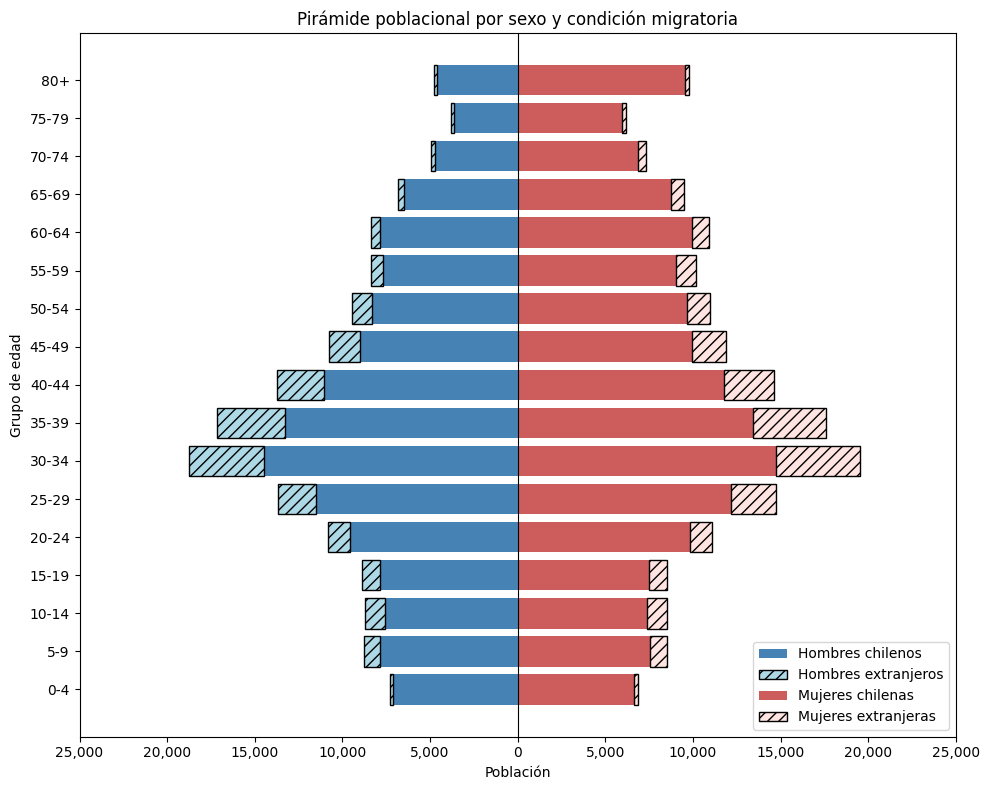

In [8]:
# -----------------------------------
# 1. Filtrar edades y nacionalidad válidas
# -----------------------------------
pyr = df[(df["edad"] != -99) & (df["p25_lug_nacimiento_rec"] != -99)].copy()

# -----------------------------------
# 2. Crear grupos de edad
# -----------------------------------
bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]

pyr["age_group"] = pd.cut(
    pyr["edad"],
    bins=bins,
    labels=labels,
    right=False
)

# -----------------------------------
# 3. Recodificar sexo y nacionalidad
# -----------------------------------
# Viendo en el diccionario de datos, las variables de sexo y lugar de nacimiento vienen codificadas de la siguiente forma:
# sexo: 1 = hombre, 2 = mujer
# p25_lug_nacimiento_rec: 1 y 2 = chileno/a, 3 = extranjero/a

pyr["sexo_cat"] = pyr["sexo"].map({
    1: "Hombre",
    2: "Mujer"
})

pyr["nac_cat"] = pyr["p25_lug_nacimiento_rec"].map({
    1: "Chileno/a",
    2: "Extranjero/a"
})

# Eliminar cualquier caso no reconocido
pyr = pyr[pyr["sexo_cat"].notna() & pyr["nac_cat"].notna() & pyr["age_group"].notna()].copy()

# -----------------------------------
# 4. Tabla de conteos
# -----------------------------------
tab = (
    pyr.groupby(["age_group", "sexo_cat", "nac_cat"], observed=False)
       .size()
       .reset_index(name="n")
)

male_chile = (
    tab[(tab["sexo_cat"] == "Hombre") & (tab["nac_cat"] == "Chileno/a")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

male_foreign = (
    tab[(tab["sexo_cat"] == "Hombre") & (tab["nac_cat"] == "Extranjero/a")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

female_chile = (
    tab[(tab["sexo_cat"] == "Mujer") & (tab["nac_cat"] == "Chileno/a")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

female_foreign = (
    tab[(tab["sexo_cat"] == "Mujer") & (tab["nac_cat"] == "Extranjero/a")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

# Hombres a la izquierda
male_chile_neg = -male_chile
male_foreign_neg = -male_foreign

# -----------------------------------
# 5. Graficar
# -----------------------------------
fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(labels))

# Hombres
ax.barh(
    y,
    male_chile_neg,
    color="steelblue",
    label="Hombres chilenos"
)

ax.barh(
    y,
    male_foreign_neg,
    left=male_chile_neg,
    color="lightblue",
    hatch="///",
    edgecolor="black",
    label="Hombres extranjeros"
)

# Mujeres
ax.barh(
    y,
    female_chile,
    color="indianred",
    label="Mujeres chilenas"
)

ax.barh(
    y,
    female_foreign,
    left=female_chile,
    color="mistyrose",
    hatch="///",
    edgecolor="black",
    label="Mujeres extranjeras"
)

# Formato
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.axvline(0, color="black", linewidth=0.8)

# Etiquetas del eje x en valor absoluto
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f"{abs(int(x)):,}" for x in xticks])

ax.set_xlabel("Población")
ax.set_ylabel("Grupo de edad")
ax.set_title("Pirámide poblacional por sexo y condición migratoria")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [9]:
# Base persona-comuna
# Base persona-comuna
dep = per.merge(
    viv[["id_vivienda", "comuna"]],
    on="id_vivienda",
    how="left"
).copy()

# Filtrar edades válidas
dep = dep[(dep["edad"].notna()) & (dep["edad"] != -99) & (dep["edad"] >= 0)].copy()

# Crear nombre de comuna a partir del código
mapa_comunas = {
    13120: "Ñuñoa",
    13129: "San Joaquín",
    13203: "San José de Maipo"
}

dep["nombre_comuna"] = dep["comuna"].map(mapa_comunas)

# Crear indicadores por tramo etario
dep["pob_0_14"] = dep["edad"].between(0, 14, inclusive="both")
dep["pob_15_64"] = dep["edad"].between(15, 64, inclusive="both")
dep["pob_65_mas"] = dep["edad"] >= 65

# Agrupar por comuna
tabla_dep = (
    dep.groupby(["comuna", "nombre_comuna"])
       .agg(
           poblacion_0_14=("pob_0_14", "sum"),
           poblacion_15_64=("pob_15_64", "sum"),
           poblacion_65_mas=("pob_65_mas", "sum")
       )
       .reset_index()
)

# Calcular dependency ratio
tabla_dep["dependency_ratio"] = (
    (tabla_dep["poblacion_0_14"] + tabla_dep["poblacion_65_mas"]) /
    tabla_dep["poblacion_15_64"]
).round(3)

# Dejar tabla final más limpia
tabla_dep = tabla_dep[[
    "nombre_comuna",
    "poblacion_0_14",
    "poblacion_15_64",
    "poblacion_65_mas",
    "dependency_ratio"
]].rename(columns={
    "nombre_comuna": "Comuna",
    "poblacion_0_14": "Población 0-14",
    "poblacion_15_64": "Población 15-64",
    "poblacion_65_mas": "Población 65+",
    "dependency_ratio": "Dependency ratio"
})

tabla_dep

,Comuna,Población 0-14,Población 15-64,Población 65+,Dependency ratio
0,Ñuñoa,31138,174549,35780,0.383
1,San Joaquín,14852,64957,15793,0.472
2,San José de Maipo,2932,11748,2761,0.485


Como se puede observar, observando los ratio podemos ver que Ñuñoa (38.3%) cumple con las expectativas al ser conocida como una comuna joven donde van a vivir los hijos después de irse de la casa de sus padres, luego vemos San Joaquín y San José de Maipo(47.2% y 48.5% respectivamente) que muestran un ratio más alto de dependencia a comparación con Ñuñoa, siendo esto más realista con el panorama de que la población chilena ha ido envejeciendo y que la natalidad no ha sabido seguir el ritmo.

1.3 Household size distribution

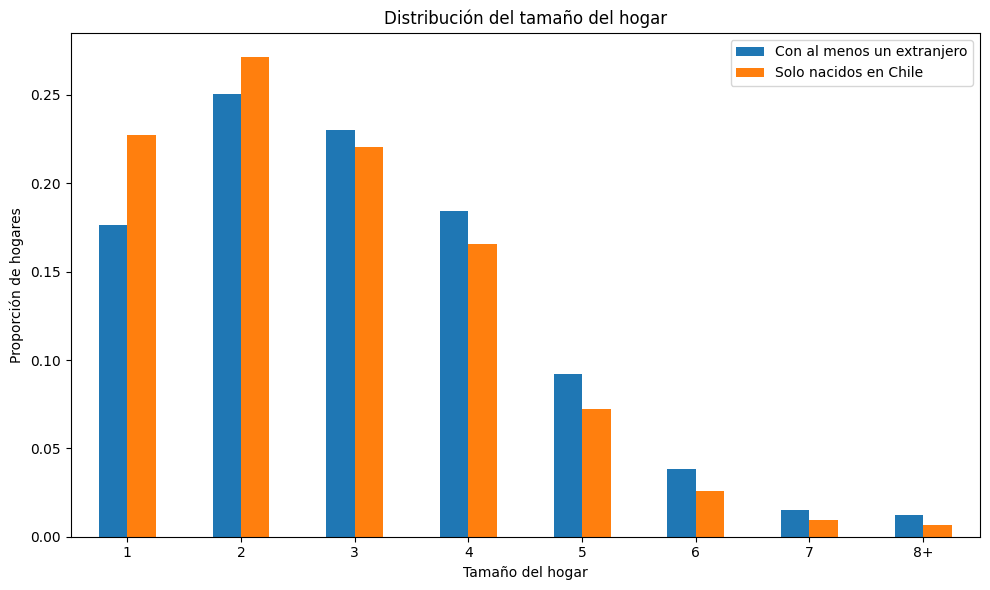

grupo,Con al menos un extranjero,Solo nacidos en Chile
tam_cat,,
1,0.177,0.227
2,0.250,0.272
3,0.230,0.221
4,0.185,0.166
5,0.092,0.073
6,0.039,0.026
7,0.015,0.010
8+,0.012,0.007


In [46]:
# Dejar solo columnas necesarias
hh = censo[["id_vivienda", "id_hogar", "id_persona", "p25_lug_nacimiento"]].dropna().copy()

# Dejar solo valores válidos: 1 y 2 = nacidos en Chile, 3 = extranjero
hh = hh[hh["p25_lug_nacimiento"].isin([1, 2, 3])].copy()

# Indicador de extranjero
hh["es_extranjero"] = (hh["p25_lug_nacimiento"] == 3).astype(int)

# Tamaño del hogar y presencia de al menos un extranjero
hogares = (
    hh.groupby(["id_vivienda", "id_hogar"], as_index=False)
      .agg(
          tam_hogar=("id_persona", "nunique"),
          extranjeros=("es_extranjero", "sum")
      )
)

# Clasificación del hogar
hogares["grupo"] = np.where(
    hogares["extranjeros"] > 0,
    "Con al menos un extranjero",
    "Solo nacidos en Chile"
)

# Categorías 1, 2, 3, ..., 8+
hogares["tam_cat"] = np.where(
    hogares["tam_hogar"] >= 8,
    "8+",
    hogares["tam_hogar"].astype(str)
)

orden = [str(i) for i in range(1, 8)] + ["8+"]

# Tabla de proporciones
tabla = pd.crosstab(
    hogares["tam_cat"],
    hogares["grupo"],
    normalize="columns"
).reindex(orden, fill_value=0)

# Gráfico
tabla.plot(kind="bar", figsize=(10, 6))
plt.title("Distribución del tamaño del hogar")
plt.xlabel("Tamaño del hogar")
plt.ylabel("Proporción de hogares")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

tabla.round(3)

# 1.3 Household size distribution

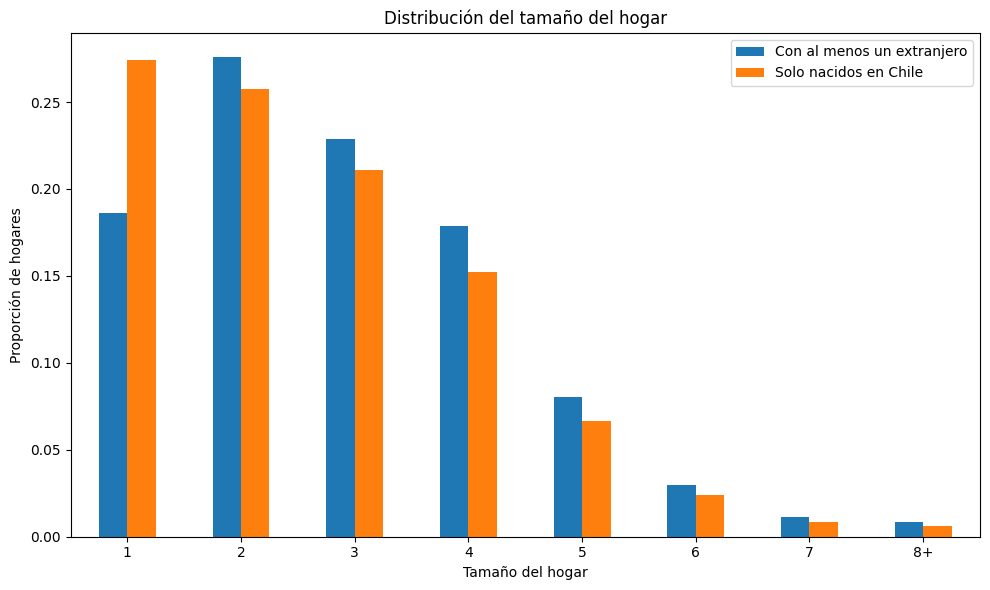

grupo,Con al menos un extranjero,Solo nacidos en Chile
tam_cat,,
1,0.186,0.274
2,0.276,0.257
3,0.229,0.211
4,0.179,0.152
5,0.081,0.067
6,0.030,0.024
7,0.011,0.009
8+,0.008,0.006


In [12]:

# Dejar solo columnas necesarias
hh = censo[["id_vivienda", "id_hogar", "id_persona", "p25_lug_nacimiento"]].dropna().copy()

# Indicador: 1 si es extranjero, 0 si no
hh["es_extranjero"] = (hh["p25_lug_nacimiento"] == 2).astype(int)

# Tamaño del hogar y si tiene al menos un extranjero
hogares = (
    hh.groupby(["id_vivienda", "id_hogar"], as_index=False)
      .agg(
          tam_hogar=("id_persona", "nunique"),
          extranjeros=("es_extranjero", "sum")
      )
)

# Clasificación del hogar
hogares["grupo"] = np.where(
    hogares["extranjeros"] > 0,
    "Con al menos un extranjero",
    "Solo nacidos en Chile"
)

# Tamaño categorizado: 1, 2, ..., 8+
hogares["tam_cat"] = np.where(hogares["tam_hogar"] >= 8, "8+", hogares["tam_hogar"].astype(str))
orden = [str(i) for i in range(1, 8)] + ["8+"]

# Tabla de proporciones
tabla = pd.crosstab(hogares["tam_cat"], hogares["grupo"], normalize="columns")

# Asegurar orden del eje x
tabla = tabla.reindex(orden, fill_value=0)

# Gráfico
tabla.plot(kind="bar", figsize=(10, 6))
plt.title("Distribución del tamaño del hogar")
plt.xlabel("Tamaño del hogar")
plt.ylabel("Proporción de hogares")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

tabla.round(3)

In [14]:
per["sit_fuerza_trabajo"].value_counts(dropna=False).sort_index()

sit_fuerza_trabajo
-99.0      2203
 1.0     195707
 2.0      12460
 3.0      95218
 NaN      48922
Name: count, dtype: int64

,Comuna,Grupo,Mean years of schooling
4,Ñuñoa,Chilean-born,14.948549
5,Ñuñoa,Foreign-born,15.787912
0,San Joaquín,Chilean-born,11.891978
1,San Joaquín,Foreign-born,11.786900
2,San José de Maipo,Chilean-born,11.398325
3,San José de Maipo,Foreign-born,13.175075


,Comuna,Grupo,Employment rate (%)
4,Ñuñoa,Chilean-born,62.206989
5,Ñuñoa,Foreign-born,79.435769
0,San Joaquín,Chilean-born,58.828422
1,San Joaquín,Foreign-born,67.812301
2,San José de Maipo,Chilean-born,61.182056
3,San José de Maipo,Foreign-born,67.840423


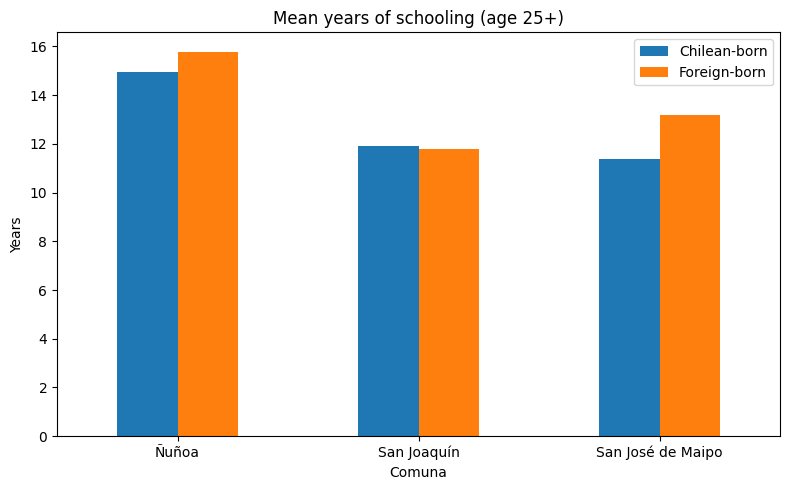

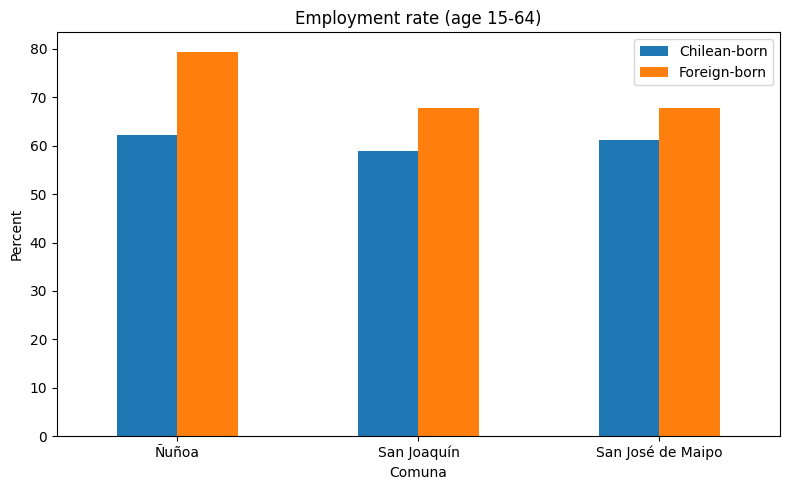

In [15]:

# Codigo de empleo según el diccionario de datos: 1 = Empleado/a, 2 = Desempleado/a, 3 = Inactivo/a
EMPLOYED_CODE = 1

# Unir personas con comuna
edu_emp = per.merge(
    viv[["id_vivienda", "comuna"]],
    on="id_vivienda",
    how="left"
).copy()

# Mapas
mapa_comunas = {
    13120: "Ñuñoa",
    13129: "San Joaquín",
    13203: "San José de Maipo"
}

mapa_nac = {
    1: "Chilean-born",
    2: "Foreign-born"
}

edu_emp["Comuna"] = edu_emp["comuna"].map(mapa_comunas)
edu_emp["Grupo"] = edu_emp["p25_lug_nacimiento"].map(mapa_nac)

# -------------------------
# 1) Mean years of schooling, age 25+
# -------------------------
esc = edu_emp[
    (edu_emp["edad"] >= 25) &
    (edu_emp["edad"] != -99) &
    (edu_emp["escolaridad"] != -99) &
    (edu_emp["p25_lug_nacimiento"].isin([1, 2]))
].copy()

tabla_esc = (
    esc.groupby(["Comuna", "Grupo"], observed=False)["escolaridad"]
       .mean()
       .reset_index(name="Mean years of schooling")
)

tabla_esc["Comuna"] = pd.Categorical(
    tabla_esc["Comuna"],
    categories=["Ñuñoa", "San Joaquín", "San José de Maipo"],
    ordered=True
)
tabla_esc = tabla_esc.sort_values(["Comuna", "Grupo"])

# -------------------------
# 2) Employment rate, age 15-64
# -------------------------
emp = edu_emp[
    (edu_emp["edad"].between(15, 64, inclusive="both")) &
    (edu_emp["edad"] != -99) &
    (edu_emp["sit_fuerza_trabajo"] != -99) &
    (edu_emp["p25_lug_nacimiento"].isin([1, 2]))
].copy()

emp["employed"] = (emp["sit_fuerza_trabajo"] == EMPLOYED_CODE).astype(int)

tabla_emp = (
    emp.groupby(["Comuna", "Grupo"], observed=False)["employed"]
       .mean()
       .mul(100)
       .reset_index(name="Employment rate (%)")
)

tabla_emp["Comuna"] = pd.Categorical(
    tabla_emp["Comuna"],
    categories=["Ñuñoa", "San Joaquín", "San José de Maipo"],
    ordered=True
)
tabla_emp = tabla_emp.sort_values(["Comuna", "Grupo"])

# -------------------------
# Tablas
# -------------------------
display(tabla_esc)
display(tabla_emp)

# -------------------------
# Gráfico 1: Schooling
# -------------------------
graf_esc = tabla_esc.pivot(index="Comuna", columns="Grupo", values="Mean years of schooling")
graf_esc.plot(kind="bar", figsize=(8, 5))
plt.title("Mean years of schooling (age 25+)")
plt.xlabel("Comuna")
plt.ylabel("Years")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

# -------------------------
# Gráfico 2: Employment
# -------------------------
graf_emp = tabla_emp.pivot(index="Comuna", columns="Grupo", values="Employment rate (%)")
graf_emp.plot(kind="bar", figsize=(8, 5))
plt.title("Employment rate (age 15-64)")
plt.xlabel("Comuna")
plt.ylabel("Percent")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

2.1 Percentage foreign-born by comuna

,Comuna,Porcentaje_extranjero
2,Ñuñoa,14.05
0,San Joaquín,14.82
1,San José de Maipo,4.76


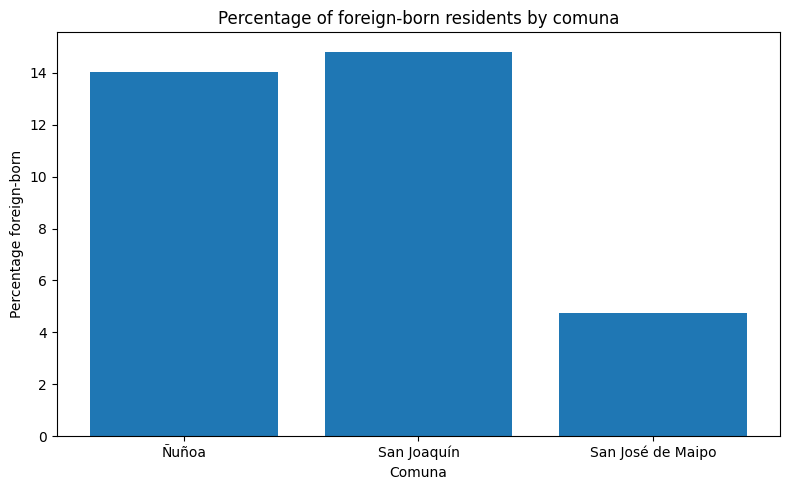

In [16]:
# Unir personas con comuna
fb = per.merge(
    viv[["id_vivienda", "comuna"]],
    on="id_vivienda",
    how="left"
).copy()

# Diccionario de nombres de comuna
mapa_comunas = {
    13120: "Ñuñoa",
    13129: "San Joaquín",
    13203: "San José de Maipo"
}

fb["Comuna"] = fb["comuna"].map(mapa_comunas)

# Dejar solo casos válidos de lugar de nacimiento
fb = fb[fb["p25_lug_nacimiento"].isin([1, 2, 3])].copy()

# Indicador de extranjero/a
fb["extranjero"] = (fb["p25_lug_nacimiento"] == 3).astype(int)

# Calcular porcentaje por comuna
tabla_fb = (
    fb.groupby("Comuna")
      .agg(
          Total_personas=("id_persona", "count"),
          Extranjeros=("extranjero", "sum")
      )
      .reset_index()
)

tabla_fb["Porcentaje_extranjero"] = (
    tabla_fb["Extranjeros"] / tabla_fb["Total_personas"] * 100
).round(2)

# Ordenar comunas
orden = ["Ñuñoa", "San Joaquín", "San José de Maipo"]
tabla_fb["Comuna"] = pd.Categorical(tabla_fb["Comuna"], categories=orden, ordered=True)
tabla_fb = tabla_fb.sort_values("Comuna")

# Mostrar tabla
display(tabla_fb[["Comuna", "Porcentaje_extranjero"]])

# Gráfico
plt.figure(figsize=(8, 5))
plt.bar(tabla_fb["Comuna"], tabla_fb["Porcentaje_extranjero"])
plt.title("Percentage of foreign-born residents by comuna")
plt.xlabel("Comuna")
plt.ylabel("Percentage foreign-born")
plt.tight_layout()
plt.show()

# 2.2 Top nationalities

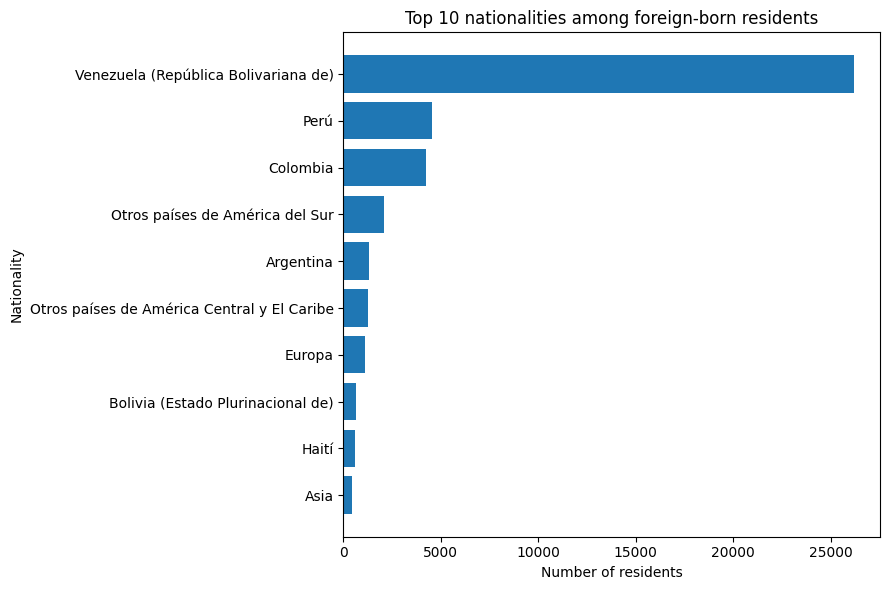

nacionalidad
Asia                                             447
Haití                                            608
Bolivia (Estado Plurinacional de)                627
Europa                                          1131
Otros países de América Central y El Caribe     1260
Argentina                                       1325
Otros países de América del Sur                 2075
Colombia                                        4254
Perú                                            4543
Venezuela (República Bolivariana de)           26220
Name: count, dtype: int64

In [35]:

# Solo residentes nacidos en el extranjero
top_nat = per[
    (per["p25_lug_nacimiento"] == 3) &
    (per["p27_nacionalidad_esp"] != -99) &
    (per["p27_nacionalidad_esp"] != 152)
].copy()

# Diccionario con las nacionalidades 
mapa_nacionalidad = {
      2: "África",
    5: "Otros países de América del Sur",
    9: "Oceanía",
    10: "Antártica (continente)",
    13: "Otros países de América Central y El Caribe",
    21: "América del Norte",
    32: "Argentina",
    68: "Bolivia (Estado Plurinacional de)",
    142: "Asia",
    150: "Europa",
    170: "Colombia",
    332: "Haití",
    604: "Perú",
    862: "Venezuela (República Bolivariana de)",
    998: "Varias comunas o países"
}

# Decodificar códigos
top_nat["nacionalidad"] = top_nat["p27_nacionalidad_esp"].map(mapa_nacionalidad)

# Por si falta algún código en el diccionario
top_nat["nacionalidad"] = top_nat["nacionalidad"].fillna(
    "Código " + top_nat["p27_nacionalidad_esp"].astype(str)
)

# Top 10 nacionalidades
tabla_top10 = top_nat["nacionalidad"].value_counts().head(10).sort_values()

# Gráfico horizontal
plt.figure(figsize=(9, 6))
plt.barh(tabla_top10.index, tabla_top10.values)
plt.title("Top 10 nationalities among foreign-born residents")
plt.xlabel("Number of residents")
plt.ylabel("Nationality")
plt.tight_layout()
plt.show()

display(tabla_top10)



Residencia_2019,En esta comuna,En otra comuna,En otro país
Comuna,,,
Ñuñoa,63.73,32.72,3.55
San Joaquín,77.16,17.37,5.48
San José de Maipo,83.42,14.35,2.23


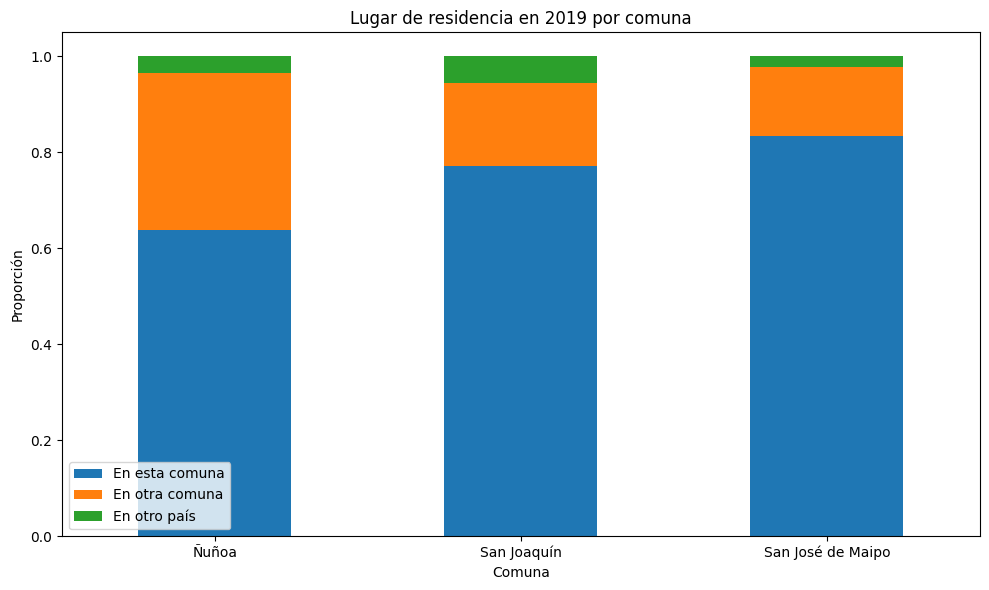

In [36]:
# Unir personas con comuna
mig = per.merge(
    viv[["id_vivienda", "comuna"]],
    on="id_vivienda",
    how="left"
).copy()

# Nombres de comuna
mapa_comunas = {
    13120: "Ñuñoa",
    13129: "San Joaquín",
    13203: "San José de Maipo"
}

# Decodificar residencia hace 5 años
mapa_resid5 = {
    2: "En esta comuna",
    3: "En otra comuna",
    4: "En otro país"
}

mig["Comuna"] = mig["comuna"].map(mapa_comunas)
mig["Residencia_2019"] = mig["p24_lug_resid5"].map(mapa_resid5)

# Filtrar: edad válida, 5 años o más, y respuestas válidas
mig = mig[
    (mig["edad"] != -99) &
    (mig["edad"] >= 5) &
    (mig["p24_lug_resid5"].isin([2, 3, 4]))
].copy()

# Tabla de proporciones por comuna
tabla_mig = pd.crosstab(
    mig["Comuna"],
    mig["Residencia_2019"],
    normalize="index"
)

# Orden
orden_comunas = ["Ñuñoa", "San Joaquín", "San José de Maipo"]
orden_resid = ["En esta comuna", "En otra comuna", "En otro país"]

tabla_mig = tabla_mig.reindex(index=orden_comunas, columns=orden_resid, fill_value=0)

# Mostrar tabla
display((tabla_mig * 100).round(2))

# Gráfico apilado
tabla_mig.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Lugar de residencia en 2019 por comuna")
plt.xlabel("Comuna")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

p26_llegada_periodo
1.0     3410
2.0     6696
3.0    20621
4.0     7877
5.0     2851
6.0     3418
7.0     2066
8.0     1503
Name: count, dtype: int64

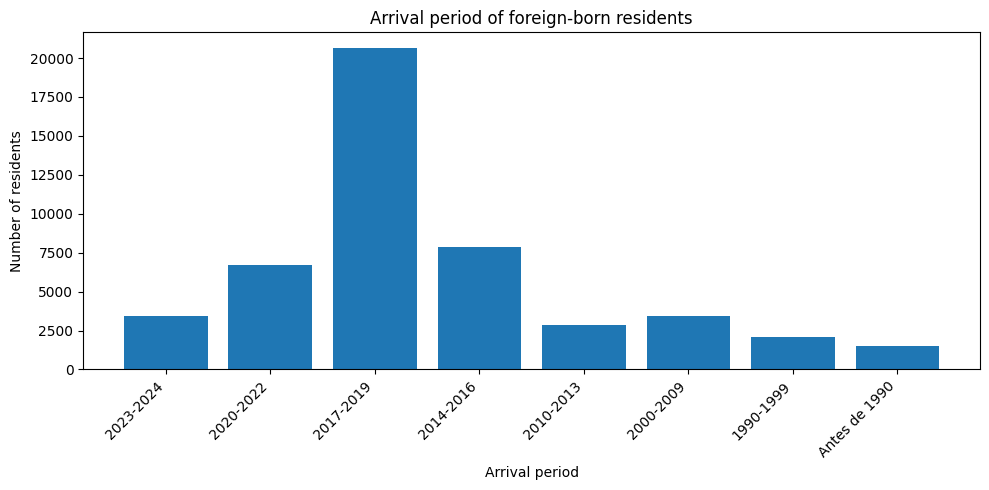

periodo_llegada
2023-2024         3410
2020-2022         6696
2017-2019        20621
2014-2016         7877
2010-2013         2851
2000-2009         3418
1990-1999         2066
Antes de 1990     1503
Name: count, dtype: int64

In [37]:
# Solo población nacida en el extranjero con periodo de llegada válido
lleg = per[
    (per["p25_lug_nacimiento"] == 3) &
    (per["p26_llegada_periodo"] != -99)
].copy()

# Reemplaza este diccionario según tu diccionario de variables
mapa_llegada = {
    1: "2023-2024",
    2: "2020-2022",
    3: "2017-2019",
    4: "2014-2016",
    5: "2010-2013",
    6: "2000-2009",
    7: "1990-1999",
    8: "Antes de 1990"
}

lleg["periodo_llegada"] = lleg["p26_llegada_periodo"].map(mapa_llegada)

# Si quieres ver primero los códigos que aparecen
display(lleg["p26_llegada_periodo"].value_counts().sort_index())

# Distribución
tabla_lleg = (
    lleg["periodo_llegada"]
    .value_counts()
    .reindex(mapa_llegada.values(), fill_value=0)
)

# Gráfico
plt.figure(figsize=(10, 5))
plt.bar(tabla_lleg.index, tabla_lleg.values)
plt.title("Arrival period of foreign-born residents")
plt.xlabel("Arrival period")
plt.ylabel("Number of residents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

tabla_lleg

In [38]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. Cargar el shapefile ────────────────────────────────────────────────────
# Cambia esta ruta a donde está tu shapefile
comunas_gdf = gpd.read_file(r"C:\Users\tomas\OneDrive\Documentos\tarea1\COMUNAS")

Para crear mapas coropléticos necesitamos un shapefile con los límites geográficos de las comunas de Chile. Importamos `geopandas`, que es la librería estándar para trabajar con datos geoespaciales en Python, y `matplotlib` para graficar.

Cargamos el shapefile con `gpd.read_file()` y luego inspeccionamos sus columnas para identificar cómo se llaman el código de comuna y el nombre, ya que estos nombres varían según la fuente del shapefile.

In [39]:
print(comunas_gdf.columns.tolist())
print(comunas_gdf[comunas_gdf["COMUNA"].str.contains("ÑUÑOA|JOAQUÍN|MAIPO", case=False, na=False)][["CUT_COM", "COMUNA"]])
print(df.columns.tolist())

['CUT_REG', 'CUT_PROV', 'CUT_COM', 'REGION', 'PROVINCIA', 'COMUNA', 'SUPERFICIE', 'geometry']
    CUT_COM             COMUNA
32    13120              Ñuñoa
37    13603      Isla de Maipo
290   13203  San José de Maipo
316   13129        San Joaquín
['id_vivienda', 'id_hogar', 'id_persona', 'sexo', 'edad', 'p27_nacionalidad_esp', 'p25_lug_nacimiento_rec', 'p24_lug_resid5', 'p25_lug_nacimiento', 'p26_llegada_periodo', 'escolaridad', 'cine11', 'sit_fuerza_trabajo', 'cod_ciuo', 'cod_caenes', 'p45_medio_transporte', 'p12_tenencia_viv', 'region', 'comuna', 'p4a_mat_paredes', 'p4b_mat_techo', 'p4c_mat_piso', 'indice_hacinamiento']


En losos 3 codigos anteriores, buscamos el nombre de las columnas de nuestro Dataframe y del Shapefile, ademas, el codigo asociado a la comuna en este, por ejemplo, el codigo de Ñuñoa es "13120"

In [40]:
#3.1
MY_COMUNAS = [13120, 13203, 13129]

# ── 1. Calcular población total por comuna desde tu df ───────────────────────
pop_by_comuna = (
    df.groupby("comuna")
    .size()
    .reset_index(name="pop_total")
)
pop_by_comuna.columns = ["codigo_comuna", "pop_total"]

# ── 2. Preparar shapefile y filtrar a tus 3 comunas ──────────────────────────
comunas_gdf["codigo_comuna"] = comunas_gdf["CUT_COM"].astype(int)

merged = comunas_gdf[comunas_gdf["codigo_comuna"].isin(MY_COMUNAS)].merge(
    pop_by_comuna, on="codigo_comuna", how="inner"
)

print(merged[["COMUNA", "codigo_comuna", "pop_total"]])

              COMUNA  codigo_comuna  pop_total
0              Ñuñoa          13120     241467
1  San José de Maipo          13203      17441
2        San Joaquín          13129      95602


En este obtuvimos la poblacion total de las tres comunas que se nos asignó

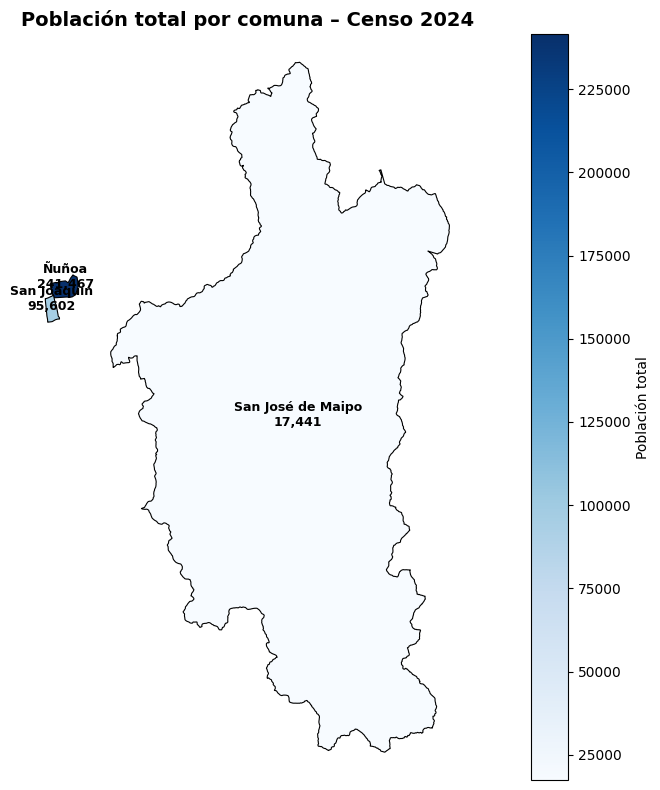

In [41]:
#3.1
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

merged.plot(
    column="pop_total",
    ax=ax,
    cmap="Blues",
    legend=True,
    legend_kwds={"label": "Población total", "orientation": "vertical"},
    edgecolor="black",
    linewidth=0.8,
)

# Etiquetas
for _, row in merged.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=f"{row['COMUNA']}\n{row['pop_total']:,}",
        xy=(centroid.x, centroid.y),
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="black",
    )

# Zoom manual solo a las 3 comunas
minx, miny, maxx, maxy = merged.geometry.total_bounds  # solo merged, no comunas_gdf
padding = 0.05
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("Población total por comuna – Censo 2024", fontsize=14, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.savefig("output/mapa_poblacion.png", dpi=150, bbox_inches="tight")
plt.show()

Graficamos el mapa coroplético usando la paleta Blues

## RESUMEN Parte 3.1 – Mapa coroplético: Población total por comuna

Para visualizar espacialmente la distribución de población, utilizamos `geopandas` para cargar un shapefile oficial de comunas de Chile y lo combinamos con los datos del Censo 2024.

Primero calculamos la población total de cada comuna contando las filas en `df` agrupadas por `comuna`. Luego hacemos un *merge* entre el GeoDataFrame (shapefile) y esta tabla, usando el código CUT como llave de unión.

El mapa resultante usa una paleta de colores secuencial (`Blues`): comunas con mayor población aparecen en azul oscuro.

Ñuñoa es la comuna más poblada con 241.467 habitantes, seguida por San Joaquín con 95.602. San José de Maipo, pese a su enorme extensión geográfica, tiene solo 17.441 habitantes, lo que refleja su carácter rural y montañoso.

In [42]:
#3.2
# ── 1. Calcular % extranjeros por comuna ─────────────────────────────────────
pct_foreign = (
    df[df["p25_lug_nacimiento"] != -99]  # excluir missing
    .groupby("comuna")
    .apply(lambda x: (x["p25_lug_nacimiento"] == 3).sum() / len(x) * 100)
    .reset_index()
)
pct_foreign.columns = ["codigo_comuna", "pct_foreign"]

# Merge con shapefile
merged2 = comunas_gdf[comunas_gdf["codigo_comuna"].isin(MY_COMUNAS)].merge(
    pct_foreign, on="codigo_comuna", how="inner"
)

print(merged2[["COMUNA", "codigo_comuna", "pct_foreign"]])

              COMUNA  codigo_comuna  pct_foreign
0              Ñuñoa          13120    14.053392
1  San José de Maipo          13203     4.756401
2        San Joaquín          13129    14.823388


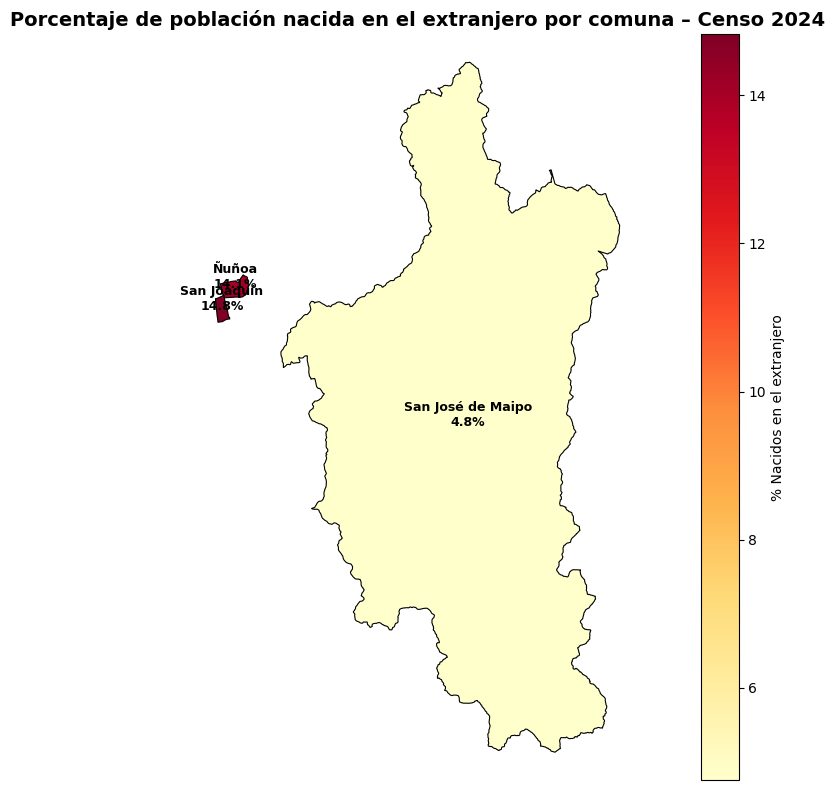

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

merged2.plot(
    column="pct_foreign",
    ax=ax,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "% Nacidos en el extranjero", "orientation": "vertical"},
    edgecolor="black",
    linewidth=0.8,
)

for _, row in merged2.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=f"{row['COMUNA']}\n{row['pct_foreign']:.1f}%",
        xy=(centroid.x, centroid.y),
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="black",
    )

minx, miny, maxx, maxy = merged2.geometry.total_bounds
padding = 0.05
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("Porcentaje de población nacida en el extranjero por comuna – Censo 2024", fontsize=14, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.savefig("output/mapa_pct_extranjeros.png", dpi=150, bbox_inches="tight")
plt.show()

Graficamos el segundo mapa usando la paleta `YlOrRd` (amarillo → rojo): los tonos más intensos indican mayor concentración de población extranjera. Se etiqueta cada comuna con su nombre y porcentaje exacto.

**Resumen**:  San Joaquín tiene el mayor porcentaje de extranjeros (14,07%), seguido por Ñuñoa (12,12%). Ambas son comunas urbanas densas de la Región Metropolitana, lo que es consistente con los patrones de asentamiento migrante. San José de Maipo, en cambio, registra solo un 3,74%, coherente con su perfil rural y menor acceso a servicios urbanos.

In [44]:
def build_summary(g):
    g = g.copy()
    
    # Filtrar missing de p25
    g_valid = g[g["p25_lug_nacimiento"] != -99]
    
    # Población
    pop_total = len(g_valid)
    pop_chilean = (g_valid["p25_lug_nacimiento"] != 3).sum()
    pop_foreign = (g_valid["p25_lug_nacimiento"] == 3).sum()
    pct_foreign = pop_foreign / pop_total * 100 if pop_total > 0 else 0

    # Edad mediana
    edad_valid = g_valid[g_valid["edad"] != -99]
    median_age_chilean = edad_valid[edad_valid["p25_lug_nacimiento"] != 3]["edad"].median()
    median_age_foreign  = edad_valid[edad_valid["p25_lug_nacimiento"] == 3]["edad"].median()

    # Escolaridad (edad 25+, sin -99)
    esc = g_valid[(g_valid["edad"] >= 25) & (g_valid["edad"] != -99) & (g_valid["escolaridad"] != -99)]
    mean_schooling_chilean = esc[esc["p25_lug_nacimiento"] != 3]["escolaridad"].mean()
    mean_schooling_foreign  = esc[esc["p25_lug_nacimiento"] == 3]["escolaridad"].mean()

    # Tasa de empleo (edad 15-64, sit_fuerza_trabajo == 1)
    emp = g_valid[(g_valid["edad"] >= 15) & (g_valid["edad"] <= 64) & (g_valid["edad"] != -99)]
    emp_chilean = emp[emp["p25_lug_nacimiento"] != 3]
    emp_foreign  = emp[emp["p25_lug_nacimiento"] == 3]
    emp_rate_chilean = (emp_chilean["sit_fuerza_trabajo"] == 1).sum() / len(emp_chilean) * 100 if len(emp_chilean) > 0 else 0
    emp_rate_foreign  = (emp_foreign["sit_fuerza_trabajo"] == 1).sum() / len(emp_foreign) * 100 if len(emp_foreign) > 0 else 0

    # Dependency ratio
    edad_v = g_valid[g_valid["edad"] != -99]["edad"]
    dep = (((edad_v < 15) | (edad_v >= 65)).sum()) / ((edad_v.between(15, 64)).sum())

    return pd.Series({
        "pop_total":               pop_total,
        "pop_chilean":             pop_chilean,
        "pop_foreign":             pop_foreign,
        "pct_foreign":             round(pct_foreign, 2),
        "median_age_chilean":      median_age_chilean,
        "median_age_foreign":      median_age_foreign,
        "mean_schooling_chilean":  round(mean_schooling_chilean, 2),
        "mean_schooling_foreign":  round(mean_schooling_foreign, 2),
        "emp_rate_chilean":        round(emp_rate_chilean, 2),
        "emp_rate_foreign":        round(emp_rate_foreign, 2),
        "dependency_ratio":        round(dep, 4),
    })

In [45]:
# Aplicar y guardar
summary = df.groupby("comuna").apply(build_summary).reset_index()
summary.rename(columns={"comuna": "codigo_comuna"}, inplace=True)

nombres = df[["comuna", "nombre_comuna"]].drop_duplicates() if "nombre_comuna" in df.columns else \
          merged[["codigo_comuna", "COMUNA"]].rename(columns={"COMUNA": "nombre_comuna"})

summary = summary.merge(nombres.rename(columns={"comuna": "codigo_comuna"}), on="codigo_comuna", how="left")

cols = ["codigo_comuna", "nombre_comuna", "pop_total", "pop_chilean", "pop_foreign",
        "pct_foreign", "median_age_chilean", "median_age_foreign",
        "mean_schooling_chilean", "mean_schooling_foreign",
        "emp_rate_chilean", "emp_rate_foreign", "dependency_ratio"]
summary = summary[cols]

display(summary)
summary.to_csv("output/tarea1_comuna_summary.csv", index=False)
print("✅ Guardado en output/tarea1_comuna_summary.csv")

,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13120,Ñuñoa,239323.0,205690.0,33633.0,14.05,38.0,36.0,15.65,16.04,75.81,84.56,0.3786
1,13129,San Joaquín,95039.0,80951.0,14088.0,14.82,39.0,33.0,11.83,13.21,63.08,77.45,0.4720
2,13203,San José de Maipo,17303.0,16480.0,823.0,4.76,39.0,34.0,12.27,12.99,64.12,80.45,0.4800


✅ Guardado en output/tarea1_comuna_summary.csv


## Parte 4 – Tabla Resumen a Nivel de Comuna

Definimos la función `build_summary` que, dado un grupo de filas correspondiente a una comuna, calcula todos los indicadores requeridos:

- **Población** total, chilena y extranjera, y porcentaje extranjero
- **Edad mediana** separada por origen (chileno/extranjero), excluyendo valores -99
- **Escolaridad media** para mayores de 25 años, también por origen
- **Tasa de empleo** para la población de 15 a 64 años, usando `sit_fuerza_trabajo == 1`
- **Índice de dependencia**: razón entre población dependiente (0-14 y 65+) y población activa (15-64)

En todos los cálculos se excluyen los valores `-99`, que el Censo usa para codificar datos faltantes.

Aplicamos `build_summary` a cada comuna usando `groupby` + `apply`. Luego agregamos el nombre de la comuna haciendo un merge con el shapefile, reordenamos las columnas según lo solicitado en el enunciado, mostramos la tabla y la guardamos como CSV en la carpeta `output/` para reutilizarla en la Tarea 3.

**Resumen:** Los datos muestran diferencias importantes entre comunas. Ñuñoa destaca por su alta escolaridad (15,67 años promedio en chilenos) y menor índice de dependencia (0,38), lo que refleja una población más educada y en edad activa. San Joaquín y San José de Maipo tienen índices de dependencia más altos (0,47 y 0,48), indicando una mayor proporción de población joven o adulta mayor. Llamativamente, los extranjeros tienen tasas de empleo más altas que los chilenos en las tres comunas, lo que sugiere que la migración está compuesta principalmente por personas en edad y disposición de trabajar.